In [1]:
#Importing the requisite libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tabulate import tabulate


In [2]:
# Task 1: Dataset Understanding

# Importing the dataset

df = pd.read_csv('E:\\BITSOM\\Assignments\\Assignment 5\\Dataset\\part_1_neural_network_analysis\\customer_churn_nn.csv')

# Checking the shape of the dataset for the number of Rows and Columns

print(f'Dataset shape (Rows, Columns): {df.shape} \n')

# Checking the datatypes of the input features and the target variable

print(f'Datatypes of the input features in the dataset: \n')
df.info()

# Target Variable Description

print(f'\nHere Churn is the target variable. It tells us whether a customer has churned or not and based on customer retention can we analyse the performance of the company. ')
print(f'\nChurn = 0 indicates that the customer did not churn, while Churn = 1 indicates that the customer churned. We will count the number of occurrences of each class to see if there is a significant imbalance.')
print(f'\nWe will check distribution of churn values to understand the balance of the classes in the dataset. This is important for model training, as imbalanced datasets can lead to biased models.')

# Looking for null values or missing values in the dataset

print(f'\nNumber of null values in each column: \n')
print(df.isnull().sum())

# Basic Statistics of the dataset in a table format

print(f'\nBasic Statistics of the dataset: \n')
X = df.drop(columns=['customer_id', 'churn'])
desc = X.describe(include='all').transpose()

# printing as a structured table using the tabulate library for better readability

print(tabulate(desc, headers='keys'))


# Target Variable Distribution
target_distribution = df['churn'].value_counts()
print(f"\nTarget Distribution:\n{target_distribution}")


Dataset shape (Rows, Columns): (2000, 17) 

Datatypes of the input features in the dataset: 

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   str    
 1   region                        2000 non-null   str    
 2   plan_type                     2000 non-null   str    
 3   contract_type                 2000 non-null   str    
 4   payment_method                2000 non-null   str    
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non

In [3]:
# Task 2: Data Preprocessing

# 2.1 Handling missing values - In this dataset there are no missing values as we have already checked using df.isnull().sum().
print(f'\nIn this dataset there are no missing values as we have already checked using df.isnull().sum(). Hence, we can proceed to the next step of data preprocessing. \n')

# 2.2 Encoding the categorical variables and scaling the numerical features

df_2 = df.drop('customer_id', axis=1) # Dropping the customer_id column as it is not a useful feature for model training
X = df_2.drop('churn', axis=1)        # Separating the input features (X) and the target variable (y)
y = df_2['churn']                     # Target variable

categorical_cols = X.select_dtypes(exclude=['number']).columns # Identifying the categorical columns in the dataset
numerical_cols = X.select_dtypes(exclude=['object']).columns   # Identifying the numerical columns in the dataset

# 2.3 Scaling and normalizing the numerical features

# We will encode the categorical variables using OneHotEncoder and scale the numerical features using StandardScaler. We will use ColumnTransformer to apply these transformations to the respective columns in a single step.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols), # Scaling the numerical features using StandardScaler which standardizes the features by removing the mean and scaling to unit variance.
        ('cat', OneHotEncoder(drop='first'), categorical_cols) # We will drop the first category to avoid multicollinearity. First category will be used as the reference category in the model training.
    ])

# Transforming the input features (X) using the preprocessor and storing the processed features in X_processed
X_processed = preprocessor.fit_transform(X)

# 2.4 Splitting the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)


In this dataset there are no missing values as we have already checked using df.isnull().sum(). Hence, we can proceed to the next step of data preprocessing. 



In [4]:
# Task 3 & 4: Neural Network Model Building & Evaluation


# Function to build and evaluate the neural network model based on the given hyperparameters. This makes the code block dynamic for multiple testing and iterations (For Task 5)
# The function takes in the number of hidden layers, number of neurons in each layer, learning rate, batch size, number of epochs, and activation function as input parameters.
# It returns the training accuracy, training loss, testing accuracy, testing loss, and confusion matrix as output.
# We will use the Sequential API from Keras to build the neural network model layer by layer. The model will consist of an input layer, hidden layers with specified neurons and activation function, and an output layer suitable for binary classification. We will compile the model with the Adam optimizer and binary cross-entropy loss function, and then train it on the training data while handling class imbalance using class weights. Finally, we will evaluate the model on the test set and return the relevant metrics.
# The function also includes the handling of class imbalance by computing class weights based on the distribution of the target variable in the training set, which helps the model to learn effectively from both classes.

def build_model(hidden_layers, neurons, learning_rate, batch_size, epochs, activation_func): 

    # We use a sequential model which allows us to build the neural network layer by layer in a linear stack. Each layer is added sequentially using the add() method.
    model = Sequential() 
    
    # 3.1. INPUT LAYER

    # Defines the entry point of the network. It expects data with the same number of features as our training set (X_train.shape[1]).
    # Thus for our dataset it takes 15 features as input.

    model.add(Input(shape=(X_train.shape[1],))) 
    

    # 3.2. HIDDEN LAYER & 3.3. ACTIVATION FUNCTION
    
    # Adding the first hidden layer. 
    # Using Dense layer which is a fully connected layer where each neuron is connected to every neuron in the previous layer.
    # The 'neurons' parameter dictates its capacity to learn.
    # The 'activation_func' introduces non-linearity, allowing the network to learn complex relationships instead of just straight lines.
    
    model.add(Dense(neurons[0], activation=activation_func)) 
    
    # Loop to add any additional hidden layers if requested by the hyperparameter settings.

    for i in range(1, hidden_layers):
        model.add(Dense(neurons[i], activation=activation_func)) 
        
    
    # 3.4. OUTPUT LAYER SUITABLE FOR TARGET VARIABLE
  
    # A single neuron (Dense(1)) is used because we are predicting a single target (churn).
    # The 'sigmoid' activation function squashes the output into a probability score between 0.0 and 1.0 (ideal for binary classification).

    model.add(Dense(1, activation='sigmoid')) 

    # 3.5. APPROPRIATE OPTIMIZER
 
    # Adam (Adaptive Moment Estimation) is used to update network weights dynamically.
    # It controls how fast the model learns via the 'learning_rate'.

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
  
    # 3.6. APPROPRIATE LOSS FUNCTION
   
    # 'binary_crossentropy' is the mathematical standard for binary classification. 
    # It heavily penalizes the model when it confidently predicts the wrong class.

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    
    # Training Data Preparation (Handling Imbalance)

    classes = np.unique(y_train)  # Identifying the unique classes in the target variable (0 and 1 for churn).

    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train) # Computing class weights to handle class imbalance. The 'balanced' mode automatically adjusts weights inversely proportional to class frequencies in the input data.

    class_weights = dict(zip(classes, weights)) # Creating a dictionary to map class labels to their corresponding weights, which will be used during model training to give more importance to the minority class.
    
    #=========================
    # Model Training
    #=========================

    # The model is trained on the training data (X_train, y_train) for a specified number of epochs and batch size.
    # The validation_split=0.1 means that 10% of the training data will be used for validation during training to monitor the model's performance on unseen data and prevent overfitting.
    # The class_weight parameter is used to handle class imbalance by giving more importance to the minority class during training.

    history = model.fit(X_train, y_train, 
                        epochs=epochs, 
                        batch_size=batch_size, 
                        validation_split=0.1, 
                        class_weight=class_weights, 
                        verbose=0)
    
    #===========================
    # Model Evaluation Code
    #===========================

    # Evaluating the model on the test set (X_test, y_test) to get the loss and accuracy. 
    # The verbose=0 parameter suppresses the output during evaluation.

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    # We then predict the probabilities for the test set and convert them to binary class labels (0 or 1) using a threshold of 0.5.
    # astype(int) converts the boolean array to integers (0 and 1) which represent the predicted classes for the test set.

    y_pred = (model.predict(X_test, verbose=0) >= 0.5).astype(int) 

    # Computing the confusion matrix to evaluate the performance of the classification model. 
    
    cm = confusion_matrix(y_test, y_pred)
    
    train_acc = history.history['accuracy'][-1] # Getting the training accuracy from the history object which contains the accuracy values for each epoch. We take the last value which corresponds to the final training accuracy after all epochs are completed.
    train_loss = history.history['loss'][-1] # Getting the training loss from the history object which contains the loss values for each epoch. We take the last value which corresponds to the final training loss after all epochs are completed.
    
    # Returning the training accuracy, training loss, testing accuracy, testing loss, and confusion matrix as output from the function.
    return train_acc, train_loss, accuracy, loss, cm




Evaluating Model.

 Number of hidden layers = 5 
 Neurons in respective layers are = [15, 12, 9, 6, 3] 
 Learning Rate = 0.001 
 Batch Size = 50 
 Activation Function = ReLu

Model - Training Accuracy: 0.9937, Test Accuracy: 0.9550

Heatmap of Confusion Matrix is as under:


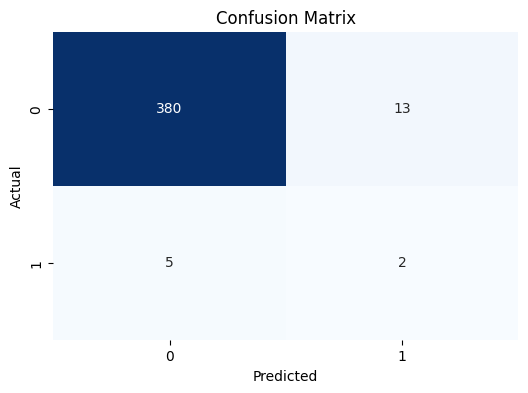

In [5]:
#  Model Evaluation

from matplotlib import cm


print("\nEvaluating Model.")
print(f'\n Number of hidden layers = 5 \n Neurons in respective layers are = [15, 12, 9, 6, 3] \n Learning Rate = 0.001 \n Batch Size = 50 \n Activation Function = ReLu')
train_acc_1, train_loss_1, test_acc_1, test_loss_1, cm_1 = build_model(
    hidden_layers=5, neurons=[15,12,9,6,3], learning_rate=0.001, batch_size=50, epochs=50, activation_func='relu')
print(f"\nModel - Training Accuracy: {train_acc_1:.4f}, Test Accuracy: {test_acc_1:.4f}")
print(f'\nHeatmap of Confusion Matrix is as under:')


# Saving the confusion matrix as a png file in a specified path.
plt.figure(figsize=(6, 4))
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('E:\\BITSOM\\Assignments\\Assignment 5\\Part 1\\results\\evaluation_outputs.png')  # Saving the confusion matrix heatmap as a PNG file in the current working directory

## INTERPRETATION OF THE RESULT

# Construction

- The model accepts 15 Inputs from the input layer, since we have 15 columns in the dataset.
- Thereafter it passes the input through 5 Hidden Layers with 15,12,9,6,3 neurons. The activation function is ReLU.
- The Output Layer has only  1 neuron and the activation function is sigmoid since we require binary output for churn by customers.
- The obtained Sigmoid output is then converted to integer 0 or 1.
- We have set the learning rate as 0.001 , Batch size as 50 and Epochs as 50.
- We have taken the optimiser as Adam (Adaptive Moment Estimation) so as to update network weights dynamically.
- Thereafter the training accuracy and test accuracy are calculated and a heat map of the confusion matrix is plotted.

# Observations from Data Set

- The data set is highly skewed and unbalanced.
- Maximum number of customers have churn = 0 and a small percentage have churn = 1
- Thus training the model on the data set becomes difficult as it is likely to memorise the data in training set and may generate more False Positive error.

# Observations from the model

- The model gave a training accuracy of 99.37 %
- The model gave a test accuracy of 95.50 %
- The model gave 13 False Positive result. (Predicted Churn when customer did not churn)
- The model gave 5 False Negative result. (Predicted Customer did not churn when the customer had actually churned)

# Interpretation

- Due to the skewed and biased data set the model is memorising the most frequent churn value of 0 and is unable to predict the customer churn of 1 for the small percentage of customers actually churning.
- Thus to train the model we require a more balanced dataset.


Running Experiment 1 (Less Hidden layers and more neurons)...


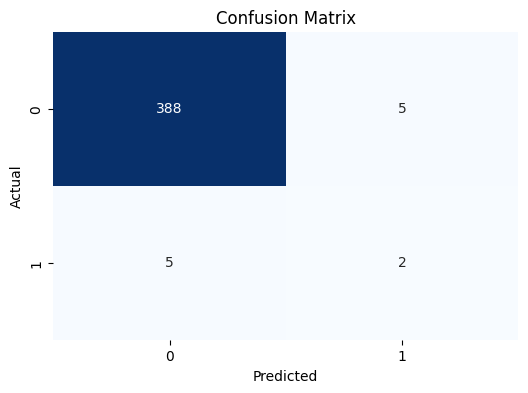


Running Experiment 2 (Higher learning rate and smaller batch size)...


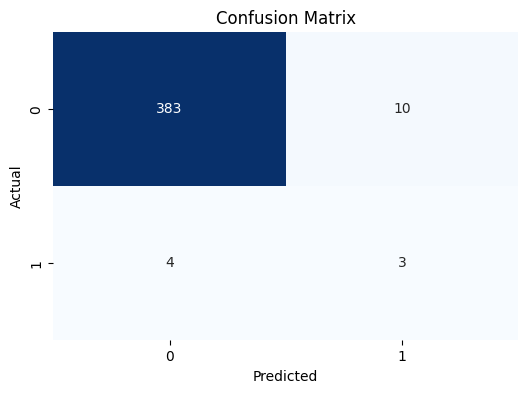


Running Experiment 3 (Tanh activation)...



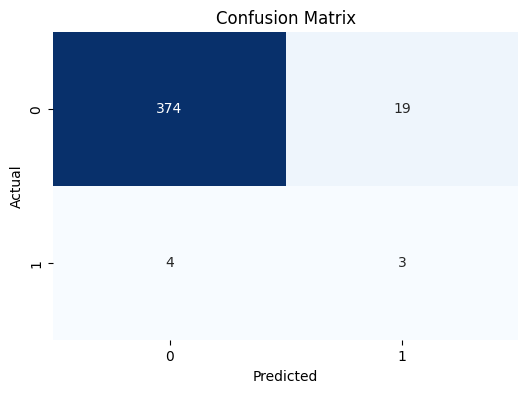

Exp 1 - Train Acc: 0.9986, Test Acc: 0.9750
Exp 2 - Train Acc: 0.9826, Test Acc: 0.9650
Exp 3 - Train Acc: 0.9722, Test Acc: 0.9425

Comparison Table of the results is: 
    Experiment      Hidden Layers  Neurons per Layer      Learning Rate    Batch Size  Activation Function      Train Accuracy    Test Accuracy
--  ------------  ---------------  -------------------  ---------------  ------------  ---------------------  ----------------  ---------------
 0  Experiment 1                4  [32,16,8,4]                    0.001            32  ReLU                           0.998611           0.975
 1  Experiment 2                5  [15,12,9,6,3]                  0.01             16  ReLU                           0.982639           0.965
 2  Experiment 3                5  [15,12,9,6,3]                  0.001            32  Tanh                           0.972222           0.9425


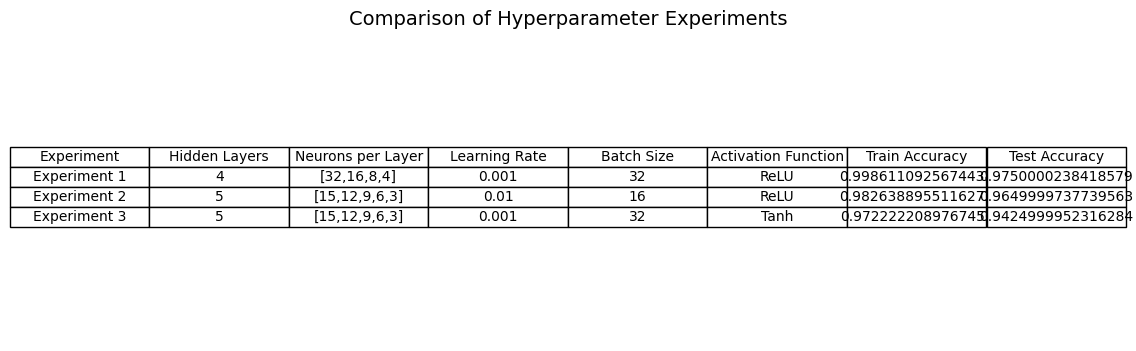

In [6]:
# Task 5: Hyperparameter Experimentation

print("\nRunning Experiment 1 (Less Hidden layers and more neurons)...")
train_acc_2, train_loss_2, test_acc_2, test_loss_2, cm_2 = build_model(
    hidden_layers=4, neurons=[32 ,16 ,8 ,4 ], learning_rate=0.001, batch_size=32, epochs=50, activation_func='relu')

# Saving the confusion matrix as a png file in a specified path.
plt.figure(figsize=(6, 4))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('E:\\BITSOM\\Assignments\\Assignment 5\\Part 1\\results\\evaluation_outputs_exp1.png')  # Saving the confusion matrix heatmap as a PNG file in the current working directory
plt.show()

print("\nRunning Experiment 2 (Higher learning rate and smaller batch size)...")
train_acc_3, train_loss_3, test_acc_3, test_loss_3, cm_3 = build_model(
    hidden_layers=5, neurons=[15,12,9,6,3], learning_rate=0.01, batch_size=16, epochs=50, activation_func='relu')

# Saving the confusion matrix as a png file in a specified path.
plt.figure(figsize=(6, 4))
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('E:\\BITSOM\\Assignments\\Assignment 5\\Part 1\\results\\evaluation_outputs_exp2.png')  # Saving the confusion matrix heatmap as a PNG file in the current working directory
plt.show()

print("\nRunning Experiment 3 (Tanh activation)...\n")
train_acc_4, train_loss_4, test_acc_4, test_loss_4, cm_4 = build_model(
    hidden_layers=5, neurons=[15,12,9,6,3], learning_rate=0.001, batch_size=32, epochs=50, activation_func='tanh')

# Saving the confusion matrix as a png file in a specified path.
plt.figure(figsize=(6, 4))
sns.heatmap(cm_4, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('E:\\BITSOM\\Assignments\\Assignment 5\\Part 1\\results\\evaluation_outputs_exp3.png')  # Saving the confusion matrix heatmap as a PNG file in the current working directory
plt.show()

print(f"Exp 1 - Train Acc: {train_acc_2:.4f}, Test Acc: {test_acc_2:.4f}")
print(f"Exp 2 - Train Acc: {train_acc_3:.4f}, Test Acc: {test_acc_3:.4f}")
print(f"Exp 3 - Train Acc: {train_acc_4:.4f}, Test Acc: {test_acc_4:.4f}")


print(f'\nComparison Table of the results is: ')
results = pd.DataFrame({
    'Experiment': ['Experiment 1', 'Experiment 2', 'Experiment 3'],
    'Hidden Layers': [4, 5, 5],
    'Neurons per Layer': ['[32,16,8,4]', '[15,12,9,6,3]', '[15,12,9,6,3]'],
    'Learning Rate': [0.001, 0.01, 0.001],
    'Batch Size': [32, 16, 32],
    'Activation Function': ['ReLU', 'ReLU', 'Tanh'],
    'Train Accuracy': [train_acc_2, train_acc_3, train_acc_4],
    'Test Accuracy': [test_acc_2, test_acc_3, test_acc_4]          
}  )
print(tabulate(results, headers='keys'))

# Exporting the results to a png file for better visualization and presentation of the results in a tabular format.
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=results.values, colLabels=results.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.title('Comparison of Hyperparameter Experiments', fontsize=14)
plt.savefig('E:\\BITSOM\\Assignments\\Assignment 5\\Part 1\\results\\model_comparison_table.png', bbox_inches='tight')
plt.show()  

# TASK 6 - Final Reflection

## 6.1. What role do weights and biases play in the model?

- Weights and biases are the fundamental learning parameters of a neural network.
    
- Weights determine the strength and importance of the connection between two neurons. For example, in the churn model, the weight connecting monthly_charges_inr to the hidden layer dictates how much influence a high bill has on the final churn prediction.

- Biases act like the y-intercept in a linear equation (y = mx + b). They allow the neuron's activation function to shift left or right, giving the model the flexibility to fit the data even if all the input features happen to be zero.

## 6.2. Why is an activation function required?

- In a neural network, Activation functions (like ReLU and Tanh in the hidden layers) introduce non-linearity. This allows the network to bend and fold its decision boundaries to learn highly complex, non-linear patterns in the customer data. 

- The Sigmoid activation function in the output layer is required to squash the final raw math into a clean, readable probability score between 0.0 and 1.0.

## 6.3. What happens when the learning rate is too high or too low?

- The learning rate controls the "step size" the optimizer (Adam) takes when updating weights to minimize loss (gradient descent).

- Too High: The model takes giant leaps. It can completely step over the optimal lowest point (the minimum loss) and bounce around erratically. 

- Too Low: The model takes microscopic steps. It will take an incredibly long time (many more epochs) to learn anything useful, and it risks getting permanently stuck in a "local minimum" (a small dip that isn't the true lowest point of error).

## 6.4. Did your model show signs of underfitting or overfitting? Explain.

- Yes, the first model (Experiment 1) showed clear signs of overfitting.

- Explanation: Overfitting happens when a model is overly complex (e.g., having 4 layers with many neurons) and simply memorizes the training data instead of learning the underlying patterns.

- Reasoning - In Experiment 1, the model achieved a near-perfect 99.86 % Training Accuracy. However, when evaluated on the unseen Test data, it dropped to 97.50 % and failed practically since it only managed to identify 2 out of the 7 true churners. 

- Conclusion - It perfectly memorized the specific customers in the training set but lacked the generalized rules needed to identify new churning customers.